In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np
from collections import Counter
import pandas as pd
import seaborn as sns
from pathlib import Path

# Build single sample dataset

In [274]:
# get real gdelt timeline
Xs = []
Xs_labels = []

data_dir = Path(r"D:/gdelt_data/input_datasets/weekly_pw_filtered_features")
counter = 0

for csv_file in data_dir.glob("*.csv"):
    df = pd.read_csv(csv_file)
    ws_pp = df.copy()
    Xs_labels.append(csv_file.stem[:-5])
    X = np.column_stack([
        ws_pp['mentions'], #Relative mentions or mentions
        ws_pp['events'],
        ws_pp['avg_sentenceid'],
        ws_pp['avg_a1co'],
        ws_pp['avg_a2co'],
        ws_pp['avg_actco'],
        ws_pp['avg_raw_text'],
        ws_pp['avg_root_event'],
        ws_pp['avg_len'],
        ws_pp['avg_goldstein'],
        ws_pp['avg_tone'],
        ws_pp['avg_confidence'],
        ws_pp['avg_lat1'],
        ws_pp['avg_lon1'],
        ws_pp['avg_lat2'],
        ws_pp['avg_lon2'],
        ws_pp['avg_lata'],
        ws_pp['avg_lona'],
        ws_pp['total_num_mentions'],
        ws_pp['total_num_sources'],
        ws_pp['total_num_articles'],
    ])

    X = (X - X.mean(axis=0)) / X.std(axis=0)
    Xs.append(X)
Xs = np.array(Xs)
print(Xs.shape)
Xs = Xs[:50,:,:]
#Xs = Xs.transpose(1,2,0)[None, :, :, :]
Xs = Xs[None, :, :, :]
print(Xs.shape)

(224, 489, 21)
(1, 50, 489, 21)


## pairwise sample data

In [243]:
Xs.shape
Xs2 = []
Xs2_labels = []
for a in range(Xs.shape[1]):
    for b in range(Xs.shape[1]):
        if b > a:
            sub = []
            sub.append(Xs[0,a,:,:])
            sub.append(Xs[0,b,:,:])
            Xs2.append(sub)
            Xs2_labels.append(Xs_labels[a] + "," + Xs_labels[b])
Xs2 = np.array(Xs2)
print(Xs2.shape)
len(Xs2_labels)

(105, 2, 489, 21)


105

In [275]:
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/trainFeatures.npy", Xs)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/validFeatures.npy", Xs)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testFeatures.npy", Xs)

dummy = np.zeros(Xs.shape[0], dtype=np.int64)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/trainTargets.npy", dummy)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/validTargets.npy", dummy)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testTargets.npy", dummy)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/trainChangePoints.npy", dummy)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/validChangePoints.npy", dummy)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testChangePoints.npy", dummy)

In [245]:
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/trainFeatures.npy", Xs2)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/validFeatures.npy", Xs2)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testFeatures.npy", Xs2)

dummy = np.zeros(Xs2.shape[0], dtype=np.int64)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/trainTargets.npy", dummy)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/validTargets.npy", dummy)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testTargets.npy", dummy)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/trainChangePoints.npy", dummy)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/validChangePoints.npy", dummy)
np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testChangePoints.npy", dummy)

In [35]:
Xs.shape

(1, 489, 21, 20)

In [36]:
tf = np.load("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/trainFeatures.npy")
tf.shape
#np.save("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/trainTargets.npy", tf)

(1, 489, 21, 20)

In [37]:
#folder = r"C:\Users\cgl_0\CORD_CPD\data\cp_gdelt"
folder = r"C:\Users\cgl_0\CORD_CPD\data\cp_loc"

for fname in os.listdir(folder):
    if fname.endswith(".npy"):
        path = os.path.join(folder, fname)

        try:
            arr = np.load(path, allow_pickle=True)

            print(f"\n{'='*60}")
            print(f"FILE: {fname}")
            print(f"type:  {type(arr)}")
            print(f"shape: {arr.shape}")
            print(f"dtype: {arr.dtype}")

            if arr.dtype == object:
                try:
                    obj = arr.item()
                    if isinstance(obj, dict):
                        print("keys:")
                        for k, v in obj.items():
                            shape = getattr(v, "shape", None)
                            print(f"  {k}: {shape}")
                except Exception:
                    print("object array")

        except Exception as e:
            print(f"{fname}: ERROR -> {e}")


FILE: cp_change_point_test_variable_5.npy
type:  <class 'numpy.ndarray'>
shape: (1,)
dtype: int64

FILE: cp_change_point_train_variable_5.npy
type:  <class 'numpy.ndarray'>
shape: (5,)
dtype: int64

FILE: cp_change_point_valid_variable_5.npy
type:  <class 'numpy.ndarray'>
shape: (1,)
dtype: int64

FILE: cp_edges1_test_variable_5.npy
type:  <class 'numpy.ndarray'>
shape: (1, 5, 5)
dtype: float64

FILE: cp_edges1_train_variable_5.npy
type:  <class 'numpy.ndarray'>
shape: (5, 5, 5)
dtype: float64

FILE: cp_edges1_valid_variable_5.npy
type:  <class 'numpy.ndarray'>
shape: (1, 5, 5)
dtype: float64

FILE: cp_edges2_test_variable_5.npy
type:  <class 'numpy.ndarray'>
shape: (1, 5, 5)
dtype: float64

FILE: cp_edges2_train_variable_5.npy
type:  <class 'numpy.ndarray'>
shape: (5, 5, 5)
dtype: float64

FILE: cp_edges2_valid_variable_5.npy
type:  <class 'numpy.ndarray'>
shape: (1, 5, 5)
dtype: float64

FILE: cp_loc_test_variable_5.npy
type:  <class 'numpy.ndarray'>
shape: (1, 100, 2, 5)
dtype: flo

In [38]:
path = (fr"C:\Users\cgl_0\CORD_CPD\data\cp_loc"fr"\cp_edges1_train_variable_5.npy")
ex = np.load(path, allow_pickle=True)
ex[0]

array([[0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.]])

In [39]:
path = (fr"C:\Users\cgl_0\CORD_CPD\data\cp_loc"fr"\cp_edges2_train_variable_5.npy")
ex = np.load(path, allow_pickle=True)
ex[0]

array([[0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.]])

In [40]:
for i in range(5):
    path = (fr"C:\Users\cgl_0\CORD_CPD\data\cp_loc"fr"\cp_edges1_train_variable_5.npy")
    ex1 = np.load(path, allow_pickle=True)
    path = (fr"C:\Users\cgl_0\CORD_CPD\data\cp_loc"fr"\cp_edges2_train_variable_5.npy")
    ex2 = np.load(path, allow_pickle=True)
    print(ex1[i].all() == ex2[i].all())

True
True
True
True
True


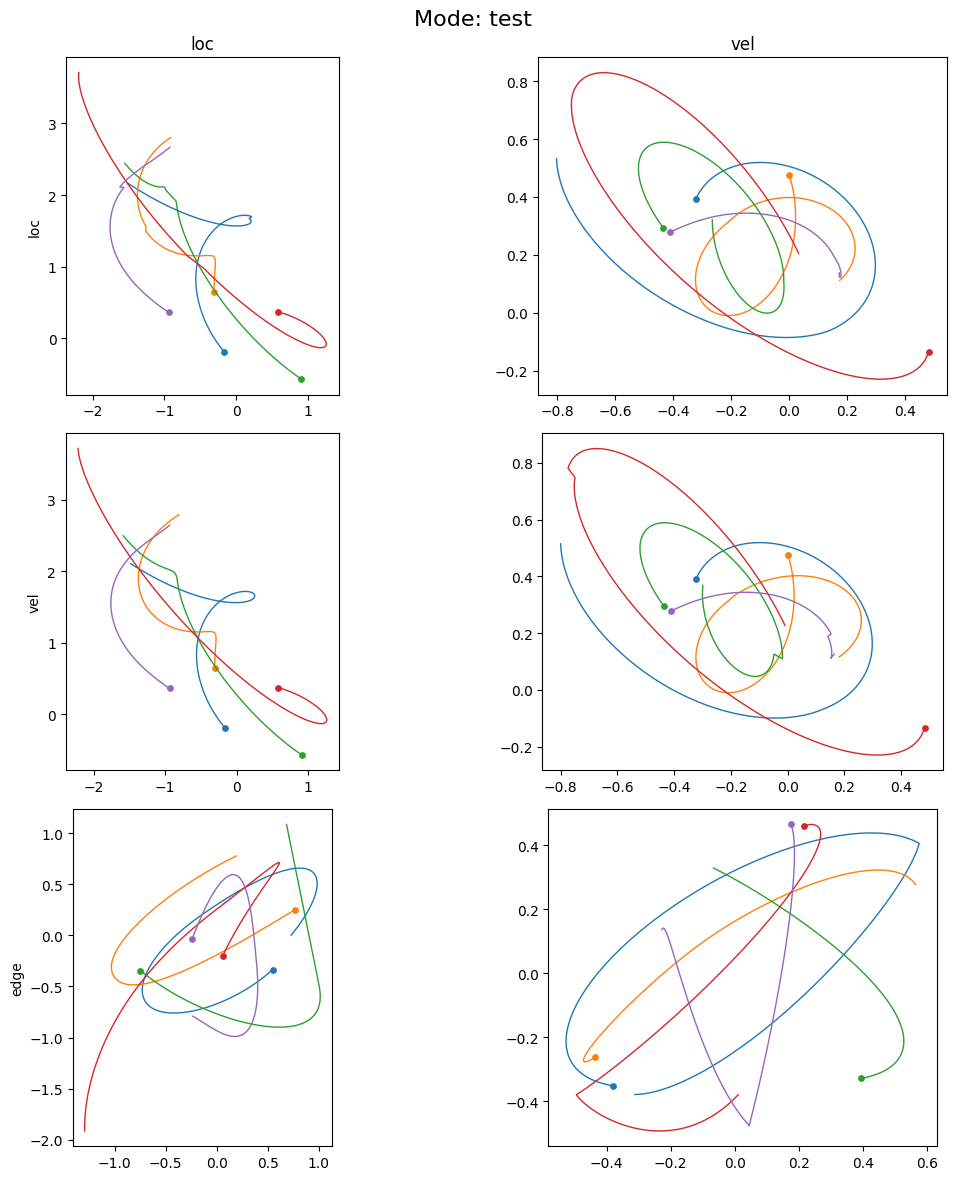

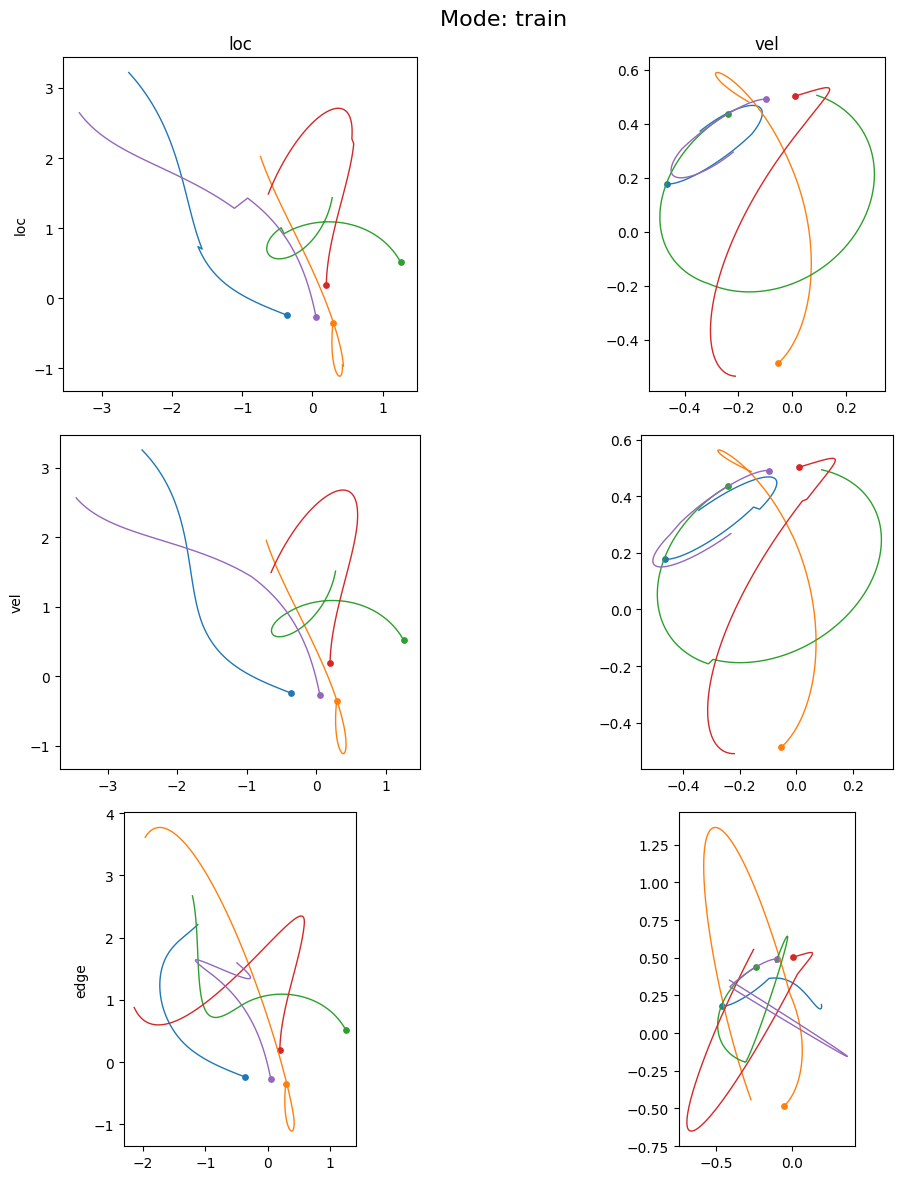

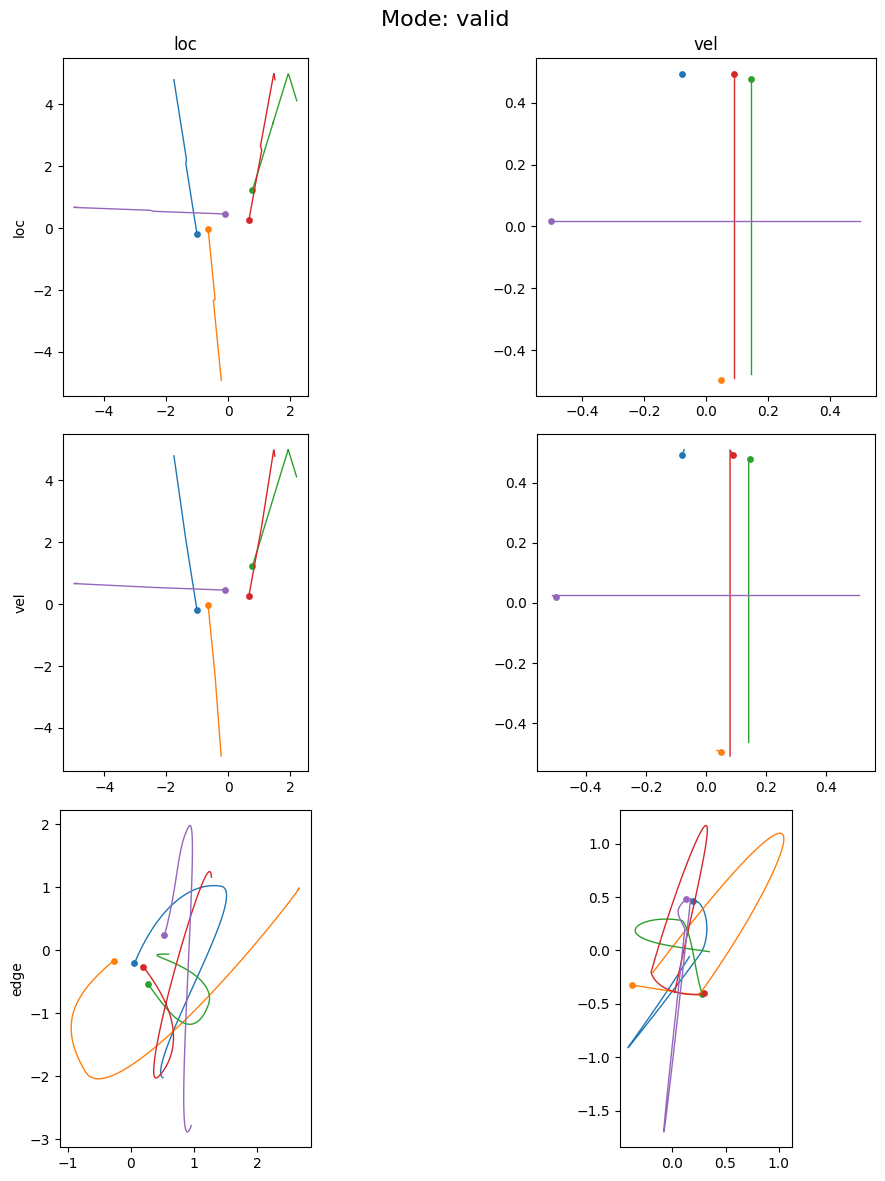

In [41]:
features = ["loc", "vel"]
vars_ = ["loc", "vel", "edge"]

for mode in ["test", "train", "valid"]:

    fig, axes = plt.subplots(
        nrows=len(vars_),
        ncols=len(features),
        figsize=(12, 12),
        squeeze=False
    )

    for row, var in enumerate(vars_):
        for col, feature in enumerate(features):

            ax = axes[row, col]

            path = (
                fr"C:\Users\cgl_0\CORD_CPD\data\cp_{var}"
                fr"\cp_{feature}_{mode}_variable_5.npy"
            )

            try:
                ex = np.load(path, allow_pickle=True)
            except FileNotFoundError:
                ax.set_title("missing")
                ax.axis("off")
                continue

            if ex.ndim == 4:
                data = ex[0]
            elif ex.ndim == 3:
                data = ex
            else:
                ax.set_title(f"{ex.ndim}D")
                ax.axis("off")
                continue

            # plot trajectories
            for i in range(data.shape[2]):
                x = data[:, 0, i]
                y = data[:, 1, i]

                ax.plot(x, y, lw=1)
                ax.scatter(x[0], y[0], s=15)

            ax.set_aspect("equal")

            if row == 0:
                ax.set_title(feature)

            if col == 0:
                ax.set_ylabel(var)

    fig.suptitle(f"Mode: {mode}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [42]:
ex[0]

array([[[ 1.93915990e-01, -3.78627164e-01,  2.83562804e-01,
          2.99404862e-01,  1.28382657e-01],
        [ 4.65371173e-01, -3.22303952e-01, -4.04418612e-01,
         -3.99437553e-01,  4.77491169e-01]],

       [[ 2.00825994e-01, -3.73554315e-01,  2.80685892e-01,
          2.95034657e-01,  1.23646920e-01],
        [ 4.66182677e-01, -3.23291071e-01, -3.98091232e-01,
         -4.01132571e-01,  4.73034422e-01]],

       [[ 2.07738679e-01, -3.67812990e-01,  2.77743423e-01,
          2.89981678e-01,  1.18988357e-01],
        [ 4.66136973e-01, -3.24356017e-01, -3.90902828e-01,
         -4.02746655e-01,  4.68570753e-01]],

       [[ 2.14632625e-01, -3.61413980e-01,  2.74743141e-01,
          2.84258828e-01,  1.14418535e-01],
        [ 4.65236875e-01, -3.25499341e-01, -3.82869433e-01,
         -4.04270455e-01,  4.64104579e-01]],

       [[ 2.21486477e-01, -3.54369406e-01,  2.71692214e-01,
          2.77880947e-01,  1.09948916e-01],
        [ 4.63487749e-01, -3.26721420e-01, -3.74009533e-

## loc

In [43]:
folder = r"C:\Users\cgl_0\CORD_CPD\data\cp_vel"

for fname in os.listdir(folder):
    if fname.endswith(".npy"):
        path = os.path.join(folder, fname)

        try:
            arr = np.load(path, allow_pickle=True)

            #print(f"\n{'='*60}")
            #print(f"FILE: {fname}")
            #print(f"type:  {type(arr)}")
            print(f"shape: {arr.shape}")
            #print(f"dtype: {arr.dtype}")

            if arr.dtype == object:
                try:
                    obj = arr.item()
                    if isinstance(obj, dict):
                        print("keys:")
                        for k, v in obj.items():
                            shape = getattr(v, "shape", None)
                            print(f"  {k}: {shape}")
                except Exception:
                    print("object array")

        except Exception as e:
            print(f"{fname}: ERROR -> {e}")

shape: (1,)
shape: (5,)
shape: (1,)
shape: (1, 5, 5)
shape: (5, 5, 5)
shape: (1, 5, 5)
shape: (1, 5, 5)
shape: (5, 5, 5)
shape: (1, 5, 5)
shape: (1, 100, 2, 5)
shape: (5, 100, 2, 5)
shape: (1, 100, 2, 5)
shape: (1, 100, 2, 5)
shape: (5, 100, 2, 5)
shape: (1, 100, 2, 5)


## inspect test, train, val dictionaries

In [46]:
path = (fr"C:\Users\cgl_0\CORD_CPD\exp\my_exp_rnn_gnn_real_data\gdelt_test_dict.npy")
test_dict = np.load(path, allow_pickle=True).item()
train_dict = np.load(fr"C:\Users\cgl_0\CORD_CPD\exp\my_exp_rnn_gnn_real_data\gdelt_train_dict.npy", allow_pickle=True).item()
valid_dict = np.load(fr"C:\Users\cgl_0\CORD_CPD\exp\my_exp_rnn_gnn_real_data\gdelt_valid_dict.npy", allow_pickle=True).item()

In [47]:
valid_dict.keys()

dict_keys(['probs', 'origs', 'recons', 'type2_score', 'type1_score', 'combined_score', 'pred_relation_cp', 'pred_mse_cp', 'pred_combined_cp'])

In [48]:
test_dict["type2_score"]

array([[0.00000000e+00, 2.67028809e-05, 1.52707100e-04, 2.18629837e-04,
        3.80051136e-03, 1.65151596e-01, 2.15851331e+00, 9.61651742e-01,
        1.14818013e+00, 2.16740823e+00],
       [0.00000000e+00, 8.41617584e-05, 1.05977058e-04, 1.26028061e-03,
        3.38892341e-02, 1.89673185e+00, 6.23869002e-01, 2.65710652e-01,
        4.82136399e-01, 7.04802692e-01],
       [0.00000000e+00, 6.36577606e-05, 6.68168068e-04, 1.53362751e-02,
        1.61919367e+00, 5.19711316e-01, 1.41848624e-01, 4.78544205e-01,
        6.78863466e-01, 3.75474715e+00],
       [0.00000000e+00, 3.13222408e-04, 5.60444593e-03, 1.05084884e+00,
        8.96622300e-01, 2.41162971e-01, 4.93348181e-01, 8.36809516e-01,
        1.60035408e+00, 8.91901016e-01],
       [0.00000000e+00, 1.94406509e-03, 2.84945011e-01, 9.17986453e-01,
        5.03615081e-01, 7.48568118e-01, 1.61295354e-01, 6.33537173e-02,
        2.43383646e-02, 1.89039159e+00],
       [0.00000000e+00, 8.84823799e-02, 4.69021082e-01, 2.84103334e-01,
   

In [49]:
test_dict["pred_combined_cp"]

array([9, 5, 4, 3, 3, 9, 9, 7, 7, 9, 9, 9, 9, 9, 9, 8, 9, 9, 9, 9, 9, 9,
       9, 9, 9, 8, 9, 9, 9, 9, 9, 9, 9, 1, 9, 9, 9, 9, 8, 8, 9, 8, 9, 9,
       9, 8, 7, 9, 8, 7, 9, 8, 7, 6, 5, 4, 4, 3, 2, 1, 9, 8, 4, 9, 9])

In [50]:
test_dict["combined_score"].shape

(65, 10)

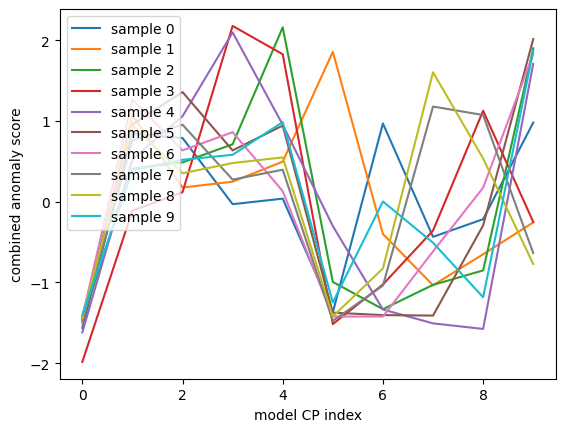

In [51]:
scores = test_dict["combined_score"]

for i in range(10):
    plt.plot(scores[i], label=f"sample {i}")

plt.xlabel("model CP index")
plt.ylabel("combined anomaly score")
plt.legend()
plt.show()

# inspect the data

In [167]:
tf = np.load("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testFeatures.npy")
#tf = np.load("C:\Users\cgl_0\OneDrive\Thesis\codes\model_codes\CORD_CPD\data\cp_gdelt\trainTargets.npy")
print(tf.shape)

obv_tf = np.load("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_obvious/testFeatures.npy")
print(obv_tf.shape)

print("Change points and targets shapes obvious data")
print(np.load("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_obvious/testChangePoints.npy").shape)
print(np.load("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_obvious/testTargets.npy").shape)

print("Change points and targets shapes real data")
print(np.load("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testChangePoints.npy").shape)
print(np.load("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_gdelt/testTargets.npy").shape)


(1, 15, 489, 21)
(25, 7, 20, 6)
Change points and targets shapes obvious data
(25,)
(25,)
Change points and targets shapes real data
(1,)
(1,)


In [246]:
#eval = np.load("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/exp/my_exp_rnn_gnn_obv_data/gdelt_valid_dict.npy", allow_pickle=True)
eval = np.load("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/exp/my_exp_rnn_gnn_real_data_more_epochs/gdelt_train_dict.npy", allow_pickle=True)
eval.item().keys()

dict_keys(['probs', 'cpds', 'relations', 'origs', 'recons', 'type2_score', 'type1_score', 'combined_score', 'pred_relation_cp', 'pred_mse_cp', 'pred_combined_cp'])

In [247]:
for col in eval.item().keys():
    print(col)
    print(eval.item()[col].shape)
    print(np.min(eval.item()[col]))
    print(np.max(eval.item()[col]))

probs
(105, 489, 2, 2)
2.2179616e-08
1.0
cpds
(105,)
0
0
relations
(105, 2, 489, 21)
0.0
0.0
origs
(105, 489, 2, 21)
-11.908527
21.759628
recons
(105, 484, 5, 2, 21)
-5.7249904
10.675014
type2_score
(105, 489)
0.0
1.9999182224273682
type1_score
(105, 489)
0.0
8.027825355529785
combined_score
(105, 489)
-3.878803431451446
9.86135448396975
pred_relation_cp
(105,)
6
485
pred_mse_cp
(105,)
21
362
pred_combined_cp
(105,)
19
444


(array([ 7.,  3.,  0.,  0.,  0.,  0.,  4.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  7.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         5.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  2.,  1.,  3.,  0.,  0.,
         0.,  0.,  0.,  0.,  2.,  0.,  0., 13.,  0.,  0.,  0.,  7.,  0.,
         0.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  1.,  1.,  0.,  0.,  0.,
         0.,  0., 11.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  3.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  7.,  3.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  1.,  0.,  7.,  0.,  0.,  0.,  0.

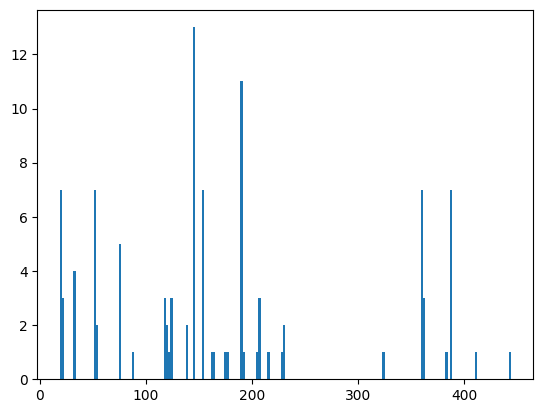

In [261]:
plt.hist(eval.item()['pred_combined_cp'], bins=200)

In [249]:
Counter(np.sort(eval.item()["pred_relation_cp"]))

Counter({np.int64(117): 5,
         np.int64(310): 4,
         np.int64(476): 4,
         np.int64(240): 3,
         np.int64(368): 3,
         np.int64(415): 3,
         np.int64(442): 3,
         np.int64(46): 2,
         np.int64(59): 2,
         np.int64(65): 2,
         np.int64(121): 2,
         np.int64(125): 2,
         np.int64(153): 2,
         np.int64(193): 2,
         np.int64(287): 2,
         np.int64(375): 2,
         np.int64(377): 2,
         np.int64(6): 1,
         np.int64(17): 1,
         np.int64(21): 1,
         np.int64(30): 1,
         np.int64(31): 1,
         np.int64(38): 1,
         np.int64(54): 1,
         np.int64(56): 1,
         np.int64(62): 1,
         np.int64(64): 1,
         np.int64(68): 1,
         np.int64(69): 1,
         np.int64(74): 1,
         np.int64(79): 1,
         np.int64(80): 1,
         np.int64(97): 1,
         np.int64(108): 1,
         np.int64(120): 1,
         np.int64(135): 1,
         np.int64(139): 1,
         np.int64(154

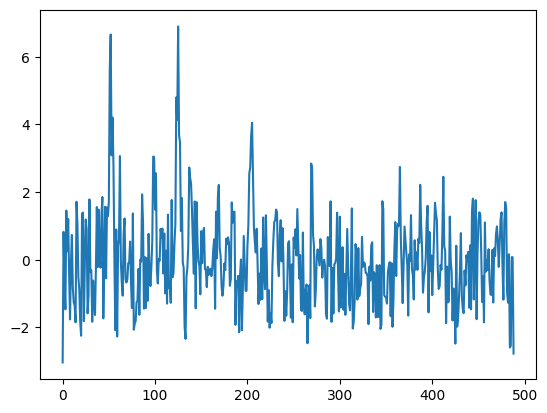

In [250]:
cs = eval.item()["combined_score"][0]
#arr = np.zeros(cs.shape[0] + cs.shape[1] - 1)
#for i in range(cs.shape[0]):
#    for j in range(cs.shape[1]):
#        arr[i+j] += cs[i][j]
plt.plot(cs)
plt.show()

In [251]:
eval.item()["type2_score"].shape

(105, 489)

In [252]:
def cal_cp_continuous(pred):
    pred = pred[..., 1]
    score = np.diff(pred, axis=0)
    score = np.sum(abs(score), axis=-1)
    score = [0] + list(score)
    return np.array(score)


def cal_cp_mean(pred):
    pred_mean = []
    ll = len(pred)
    w = 5
    for i in range(w - 1, ll):
        pred_mean.append(np.mean(pred[i - w + 1:i + 1], 0))
    pred_mean = np.array(pred_mean)
    pred_mean = np.argmax(pred_mean, -1)
    score = np.diff(pred_mean, axis=0)
    score = np.sum(abs(score), axis=-1)
    score = [0] * w + list(score)
    return np.array(score)


def cal_cp_from_output(output, fun=cal_cp_continuous):
    n = len(output)
    scores = []
    for i in range(n):
        scores.append(fun(output[i]))
    return np.array(scores)

# make obvious change point data

In [253]:
# look at original fake data
ocp = np.load("C:/Users/cgl_0/OneDrive/Thesis/codes/model_codes/CORD_CPD/data/cp_obvious/trainFeatures.npy", allow_pickle=True)
print(f"ocp shape: {ocp.shape}")

ocp shape: (150, 7, 20, 6)


In [254]:
ocp[0,0,0,0]

np.float32(0.015235854)

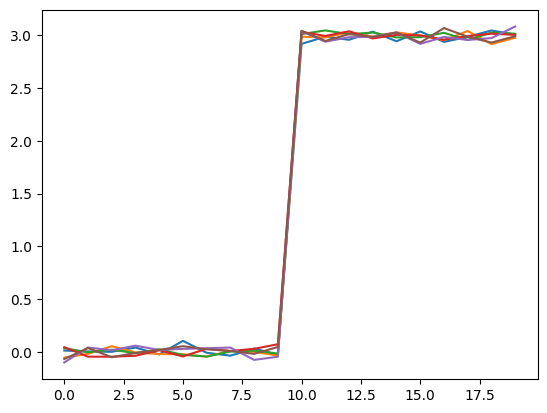

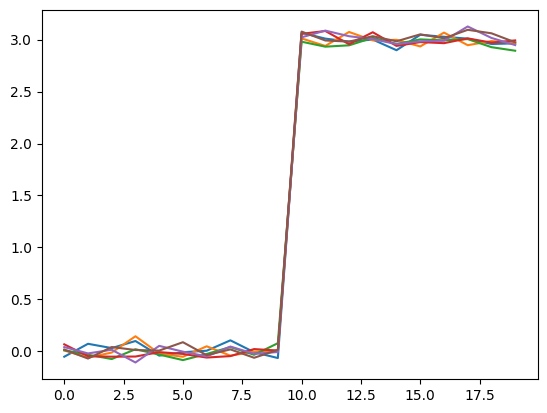

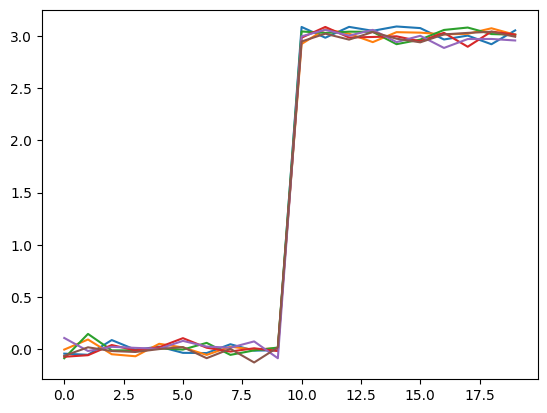

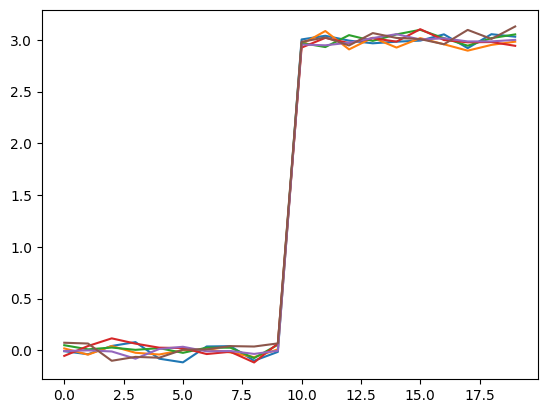

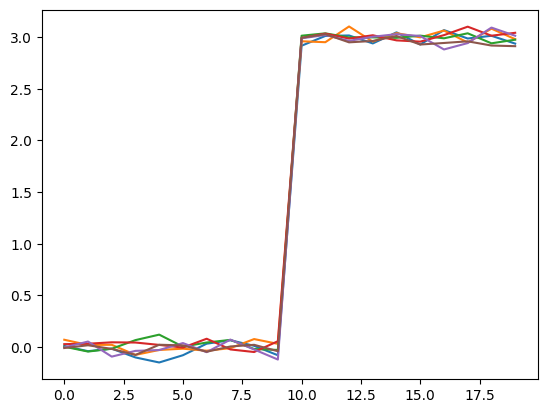

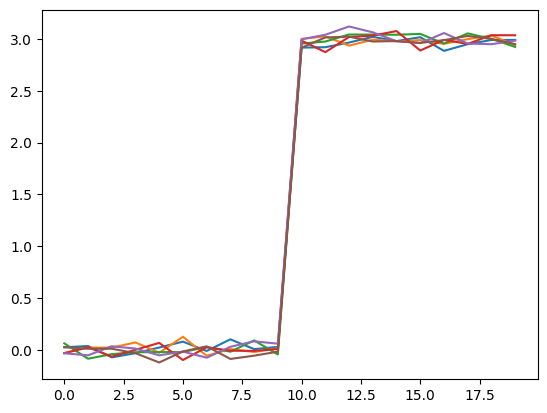

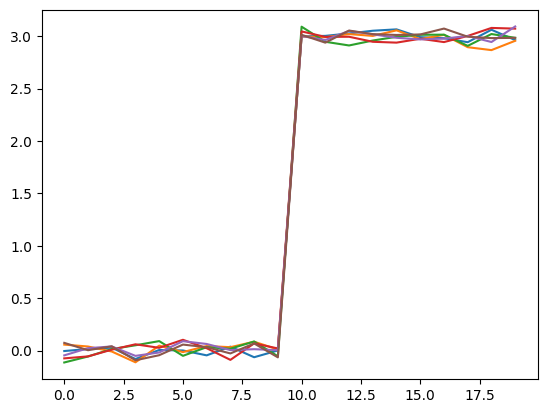

In [255]:
ocp[0].shape
#print one sample 
for j in range(7):
    for i in range(6):
        plt.plot(ocp[0,j,:,i])
    plt.show()

In [256]:
#plt.plot(X_train[:,3,0,0])

In [257]:
def edge_probs_to_adjacency(probs, num_atoms, edge_type=1):
    """
    probs:
        [batch, timesteps, num_edges, edge_types]

    returns:
        [batch, timesteps, num_atoms, num_atoms]
    """
    probs = np.asarray(probs)

    batch_size, timesteps, num_edges, _ = probs.shape

    expected_edges = num_atoms * (num_atoms - 1)
    if num_edges != expected_edges:
        raise ValueError(
            f"Expected {expected_edges} directed edges for "
            f"{num_atoms} atoms, but got {num_edges}."
        )

    off_diag = np.ones((num_atoms, num_atoms), dtype=bool)
    np.fill_diagonal(off_diag, False)

    senders, receivers = np.where(off_diag)

    adjacency = np.zeros(
        (batch_size, timesteps, num_atoms, num_atoms),
        dtype=probs.dtype,
    )

    adjacency[:, :, senders, receivers] = probs[:, :, :, edge_type]

    return adjacency

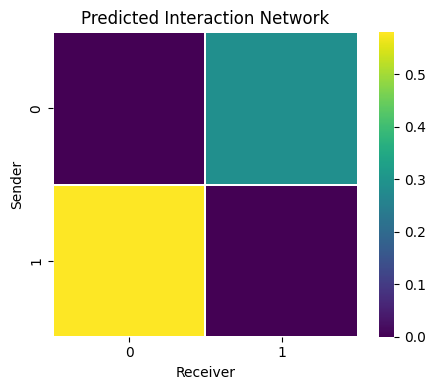

In [271]:
am = np.mean(edge_probs_to_adjacency(eval.item()["probs"], eval.item()["relations"].shape[1])[55], axis=0)

plt.figure(figsize=(5, 4))

sns.heatmap(
    am,
    cmap="viridis",      # or "coolwarm"
    square=True,
    cbar=True,
    linewidths=0.2,
    linecolor="white"
)

plt.title("Predicted Interaction Network")
plt.xlabel("Receiver")
plt.ylabel("Sender")
plt.tight_layout()
plt.show()

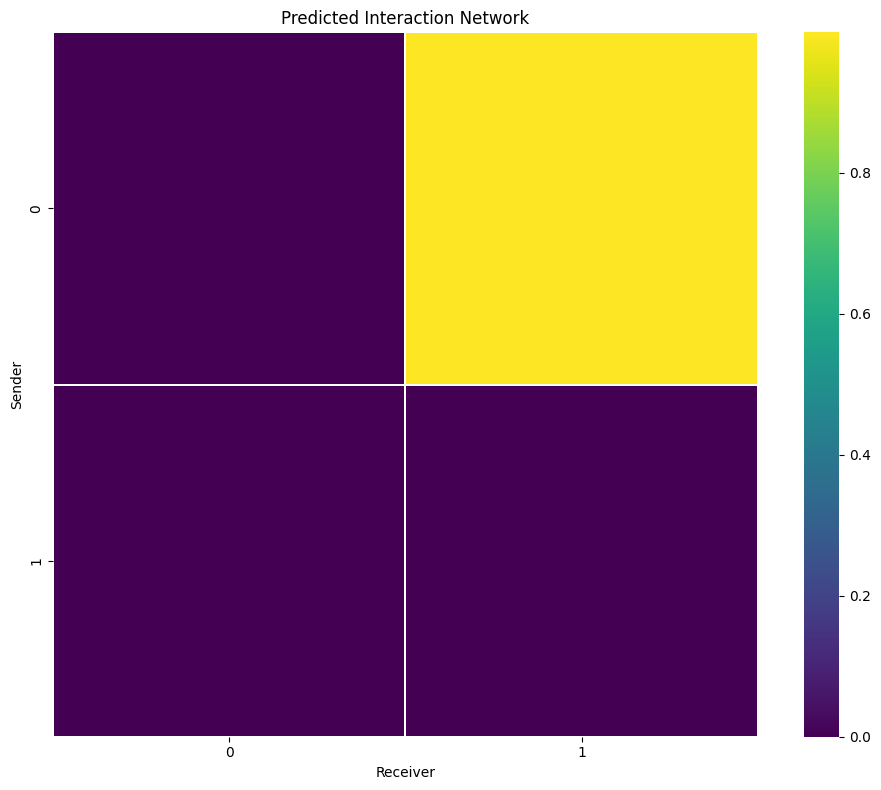

In [264]:
am = edge_probs_to_adjacency(eval.item()["probs"], eval.item()["relations"].shape[1])[2][220]

plt.figure(figsize=(10, 8))

sns.heatmap(
    am,
    cmap="viridis",      # or "coolwarm"
    square=True,
    cbar=True,
    linewidths=0.2,
    linecolor="white"
)

plt.title("Predicted Interaction Network")
plt.xlabel("Receiver")
plt.ylabel("Sender")
plt.tight_layout()
plt.show()